# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

## Inicialización

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns
from scipy import stats as st
from math import factorial
from scipy.stats import binom
from scipy.stats import norm
from scipy.stats import ttest_ind

## Cargar datos

In [ ]:
megaline_calls = pd.read_csv("/content/megaline_calls.csv")
megaline_internet = pd.read_csv("/content/megaline_internet.csv")
megaline_messages = pd.read_csv("/content/megaline_messages.csv")
megaline_plans = pd.read_csv("/content/megaline_plans.csv")
megaline_users = pd.read_csv("/content/megaline_users.csv")

## Preparar los datos

In [ ]:
display(megaline_users.sample(5))


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
69,1069,Dino,Fry,31,"Houston-The Woodlands-Sugar Land, TX MSA",2018-09-17,ultimate,NaN
459,1459,Santos,Head,40,"San Francisco-Oakland-Berkeley, CA MSA",2018-04-27,ultimate,NaN
334,1334,Donovan,Horton,34,"Seattle-Tacoma-Bellevue, WA MSA",2018-03-08,surf,NaN
162,1162,Mark,Farley,20,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-07-12,ultimate,NaN
66,1066,Ariel,Woods,61,"Boston-Cambridge-Newton, MA-NH MSA",2018-03-08,surf,NaN


In [ ]:
display(megaline_internet.sample(5))


,id,user_id,session_date,mb_used
71532,1334_100,1334,2018-11-11,991.19
97867,1460_590,1460,2018-12-28,428.55
28185,1128_339,1128,2018-07-06,414.25
54162,1246_63,1246,2018-03-09,46.88
39933,1180_177,1180,2018-12-15,169.88


In [ ]:
display(megaline_calls.sample(5))


,id,user_id,call_date,duration
61926,1223_79,1223,2018-09-18,12.63
72690,1257_430,1257,2018-12-14,8.83
122301,1432_151,1432,2018-11-30,5.20
45988,1167_71,1167,2018-07-14,15.50
207,1001_379,1001,2018-12-01,16.91


In [ ]:
display(megaline_messages.sample(5))


,id,user_id,message_date
20497,1130_172,1130,2018-12-25
17742,1115_257,1115,2018-12-03
48311,1324_1045,1324,2018-10-14
45089,1303_8,1303,2018-12-25
22791,1136_325,1136,2018-11-04


## Tarifas

In [ ]:
display(megaline_plans)
megaline_plans.info()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes


En una primera observación:
se debe cambiar el nombre de la columna plan_name por plan para que coincida  con la columna plan del df user.

Ademas convertir de MB a GB para ser más coherente cuando haya que hacer multiplicaciones de GB extras a pagar.




## Corregir datos

In [ ]:
megaline_plans.rename(columns={'plan_name' : 'plan'}, inplace = True)

megaline_plans.rename(columns={'mb_per_month_included': 'gb_per_month_included'}, inplace =True)
megaline_plans['gb_per_month_included'] = megaline_plans['gb_per_month_included'] / 1024
print(megaline_plans)

   messages_included  gb_per_month_included  minutes_included  \
0                 50                   15.0               500   
1               1000                   30.0              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute      plan  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


## Usuarios/as

In [ ]:
megaline_users.info()
print("""
cantidad de usuarios registrados en surf:""", megaline_users['user_id'][megaline_users['plan'] == 'surf'].nunique(),
"""
cantidad de usuarios registrados en ultimate:""", megaline_users['user_id'][megaline_users['plan'] == 'ultimate'].nunique())

print("cantidad de datos duplicados: ", megaline_users.duplicated().sum())
print("""
cantidad de datos ausentes:
""",megaline_users.isna().sum())
megaline_users['age'].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB

cantidad de usuarios registrados en surf: 339 
cantidad de usuarios registrados en ultimate: 161
cantidad de datos duplicados:  0

cantidad de datos ausentes:
 user_id         0
first_name      0
last_name       0
age             0
city            0
reg_date        0
plan            0
churn_date    466
dtype: int64


,age
count,500.000000
mean,45.486000
std,16.972269
min,18.000000
25%,30.000000
50%,46.000000
75%,61.000000
max,75.000000


In [ ]:
megaline_users.sample(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
346,1346,Emmie,Gonzalez,59,"Tucson, AZ MSA",2018-04-26,ultimate,NaN
204,1204,Sherly,Levy,44,"Chicago-Naperville-Elgin, IL-IN-WI MSA",2018-08-20,ultimate,NaN
249,1249,Kelly,Goodman,41,"Cincinnati, OH-KY-IN MSA",2018-05-14,ultimate,NaN
299,1299,Keitha,Harrison,64,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-01-19,surf,NaN
478,1478,Elane,David,51,"Portland-Vancouver-Hillsboro, OR-WA MSA",2018-06-28,ultimate,NaN


La edad minima en los usuarios es de 18, la máxima de 75 y la mediana es de 46 que es casi igual a la media (45)

Los 'users' activos en el plan aparecen en la tabla como NaN, que es necesario reemplazar para evitar confusiones.


### Corregir los datos

In [ ]:
megaline_users['churn_date'] = megaline_users['churn_date'].fillna('active')
megaline_users['churn_date'].isna().sum()
print(megaline_users.sample(5))

     user_id first_name  last_name  age  \
291     1291    Angeles      Mejia   65   
233     1233      Janee    Perkins   33   
315     1315       Mora  Schroeder   45   
492     1492      Elvie      Jones   63   
419     1419      Bryon     Gordon   45   

                                        city    reg_date  plan  churn_date  
291     Indianapolis-Carmel-Anderson, IN MSA  2018-01-29  surf      active  
233    Atlanta-Sandy Springs-Roswell, GA MSA  2018-09-11  surf      active  
315                     Raleigh-Cary, NC MSA  2018-04-26  surf  2018-10-03  
492  Portland-Vancouver-Hillsboro, OR-WA MSA  2018-03-07  surf      active  
419            Phoenix-Mesa-Chandler, AZ MSA  2018-03-29  surf      active  


## Llamadas

In [ ]:

megaline_calls.info()

print("cantidad datos duplicados: ", megaline_calls.duplicated().sum())
print("""
cantidad datos ausentes:
""", megaline_calls.isna().sum())
megaline_calls['duration'].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
cantidad datos duplicados:  0

cantidad datos ausentes:
 id           0
user_id      0
call_date    0
duration     0
dtype: int64


,duration
count,137735.000000
mean,6.745927
std,5.839241
min,0.000000
25%,1.290000
50%,5.980000
75%,10.690000
max,37.600000


In [ ]:
megaline_calls.sample(5)

,id,user_id,call_date,duration
21442,1079_155,1079,2018-12-31,6.39
77887,1279_15,1279,2018-12-07,9.26
125614,1445_29,1445,2018-07-04,7.83
1263,1007_284,1007,2018-11-03,8.07
3574,1012_14,1012,2018-12-12,3.51


Registro de más de 137000 llamadas registradas de 481 usuarios.

No se observan datos nulos o ausentes.

Las llamadas que se observan registradas con 00 sugiere que son de segundos y no llegan al minuto


### Enriquecer los datos

In [ ]:
megaline_calls['user_id'].nunique()
megaline_calls['call_date'] = pd.to_datetime(megaline_calls['call_date'])
megaline_calls['month'] = megaline_calls['call_date'].dt.month
megaline_calls['day'] = megaline_calls['call_date'].dt.day
print(megaline_calls.sample(5))

              id  user_id  call_date  duration  month  day
119745  1417_376     1417 2018-07-22      4.37      7   22
92084   1330_353     1330 2018-12-25      5.18     12   25
54556   1196_444     1196 2018-04-06      5.40      4    6
74795    1264_46     1264 2018-12-16      4.53     12   16
18339   1071_104     1071 2018-08-31      0.16      8   31


## Mensajes

In [ ]:
megaline_messages.info()
print('cantidad de usuarios que enviaron al menos un sms: ', megaline_messages['user_id'].nunique())
print("cantidad datos duplicados: ", megaline_messages.duplicated().sum())
print("""cantidad datos ausentes:
""", megaline_messages.isna().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
cantidad de usuarios que enviaron al menos un sms:  402
cantidad datos duplicados:  0
cantidad datos ausentes:
 id              0
user_id         0
message_date    0
dtype: int64


In [ ]:

megaline_messages.sample(5)

,id,user_id,message_date
6832,1057_156,1057,2018-11-14
72512,1470_140,1470,2018-10-27
6271,1055_389,1055,2018-07-14
23608,1144_69,1144,2018-08-04
7285,1059_157,1059,2018-09-09


Más de 76000 registros de mensajes de 402 usuarios.

No se observan datos nulos o ausentes, tampoco errores o datos confusos.

### Enriquecer los datos

In [ ]:
megaline_messages['message_date'] = pd.to_datetime(megaline_messages['message_date'])
megaline_messages['month'] = megaline_messages['message_date'].dt.month
megaline_messages['day'] = megaline_messages['message_date'].dt.day
print(megaline_messages.sample(5))

             id  user_id message_date  month  day
63842   1407_54     1407   2018-12-27     12   27
42935  1281_191     1281   2018-11-14     11   14
9604   1069_905     1069   2018-12-08     12    8
62836  1396_120     1396   2018-11-05     11    5
74964   1489_39     1489   2018-11-21     11   21


## Internet

In [ ]:
megaline_internet.info()
print('cantidad de usuarios que consumieron al menos un MB: ', megaline_internet['user_id'].nunique())
print("cantidad datos duplicados: ", megaline_internet.duplicated().sum())
print("""cantidad datos ausentes:
""", megaline_internet.isna().sum())
megaline_internet['mb_used'].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
cantidad de usuarios que consumieron al menos un MB:  489
cantidad datos duplicados:  0
cantidad datos ausentes:
 id              0
user_id         0
session_date    0
mb_used         0
dtype: int64


,mb_used
count,104825.000000
mean,366.713701
std,277.170542
min,0.000000
25%,136.080000
50%,343.980000
75%,554.610000
max,1693.470000


In [ ]:
megaline_internet.sample(5)

,id,user_id,session_date,mb_used
91040,1419_10,1419,2018-12-09,381.33
28235,1130_20,1130,2018-10-30,361.37
79749,1373_28,1373,2018-12-15,573.65
87654,1405_529,1405,2018-12-19,0.00
78435,1366_124,1366,2018-10-16,12.16


Se obtuvieron 104000+ registros de 489 usuarios.

No se observan datos duplicados o ausentes.

se hace la conversión: 1000MB = 1GB

La media de uso de MB es de 366 (0.366GB), con una mediana de 343 (0.343) y una máxima de 1693 (1.693GB).

### Corregir los datos

In [ ]:
megaline_internet.rename(columns={'mb_used': 'gb_used'}, inplace=True)
megaline_internet['gb_used'] = megaline_internet['gb_used'] / 1024


### Enriquecer los datos

In [ ]:
megaline_internet['session_date'] = pd.to_datetime(megaline_internet['session_date'])
megaline_internet['month'] = megaline_internet['session_date'].dt.month
megaline_internet['day'] = megaline_internet['session_date'].dt.day
print(megaline_internet.sample(5))

             id  user_id session_date   gb_used  month  day
87440  1405_207     1405   2018-07-11  0.577373      7   11
15600  1071_201     1071   2018-11-04  0.000000     11    4
65894   1305_69     1305   2018-08-10  0.053789      8   10
16672   1076_22     1076   2018-09-21  0.702607      9   21
12164  1059_273     1059   2018-12-19  0.480635     12   19


## Estudiar las condiciones de las tarifas

In [ ]:
print(megaline_plans)

   messages_included  gb_per_month_included  minutes_included  \
0                 50                   15.0               500   
1               1000                   30.0              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute      plan  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


## Agrego datos por usuario


In [ ]:
user_calls_month = megaline_calls.groupby(['user_id', 'month'])['id'].count().reset_index()

user_calls_month.rename(columns={'id': 'calls_amount'}, inplace=True)
print(user_calls_month.sample(10))

      user_id  month  calls_amount
983      1212      7             2
255      1059      7           100
1398     1312      5            60
91       1027     10            58
81       1022     11            72
992      1214      2            63
358      1076     11            57
1564     1346      7            45
319      1068     12            39
776      1166      9            18


In [ ]:
user_calls_duration_month = megaline_calls.groupby(['user_id', 'month'])['duration'].sum()
print(user_calls_duration_month)


user_id  month
1000     12       116.83
1001     8        171.14
         9        297.69
         10       374.11
         11       404.59
                   ...  
1498     12       324.77
1499     9        330.37
         10       363.28
         11       288.56
         12       468.10
Name: duration, Length: 2258, dtype: float64


In [ ]:
user_sms_month = megaline_messages.groupby(['user_id', 'month'])['id'].count().reset_index()

user_sms_month.rename(columns={'id': 'amount_sms'}, inplace=True)
print(user_sms_month)

      user_id  month  amount_sms
0        1000     12          11
1        1001      8          30
2        1001      9          44
3        1001     10          53
4        1001     11          36
...       ...    ...         ...
1801     1496      9          21
1802     1496     10          18
1803     1496     11          13
1804     1496     12          11
1805     1497     12          50

[1806 rows x 3 columns]


In [ ]:
user_gb = megaline_internet.groupby(['user_id', 'month'])['gb_used'].sum()
print(user_gb)

user_id  month
1000     12        1.856904
1001     8         6.756982
         9        13.002754
         10       21.807119
         11       18.070605
                    ...    
1498     12       22.595400
1499     9        12.680430
         10       19.035576
         11       16.419756
         12       21.542197
Name: gb_used, Length: 2277, dtype: float64


In [ ]:
user_data = pd.merge(user_calls_month, user_calls_duration_month, on=['user_id', 'month'])
user_data = pd.merge(user_data, user_sms_month, on=['user_id', 'month'])
user_data = pd.merge(user_data, user_gb, on=['user_id', 'month'])
user_data['gb_used'] = user_data['gb_used'].round(2)
print(user_data)

      user_id  month  calls_amount  duration  amount_sms  gb_used
0        1000     12            16    116.83          11     1.86
1        1001      8            27    171.14          30     6.76
2        1001      9            49    297.69          44    13.00
3        1001     10            65    374.11          53    21.81
4        1001     11            64    404.59          36    18.07
...       ...    ...           ...       ...         ...      ...
1754     1496      9            52    389.94          21    16.01
1755     1496     10            46    301.16          18    13.95
1756     1496     11            39    291.88          13     8.35
1757     1496     12            40    278.61          11    16.05
1758     1497     12            54    276.53          50    10.85

[1759 rows x 6 columns]


In [ ]:
sum_df = pd.merge(user_data, megaline_users[['user_id', 'plan']], how='left')
sum_df = sum_df.reset_index(drop=True)
print(sum_df)

      user_id  month  calls_amount  duration  amount_sms  gb_used      plan
0        1000     12            16    116.83          11     1.86  ultimate
1        1001      8            27    171.14          30     6.76      surf
2        1001      9            49    297.69          44    13.00      surf
3        1001     10            65    374.11          53    21.81      surf
4        1001     11            64    404.59          36    18.07      surf
...       ...    ...           ...       ...         ...      ...       ...
1754     1496      9            52    389.94          21    16.01      surf
1755     1496     10            46    301.16          18    13.95      surf
1756     1496     11            39    291.88          13     8.35      surf
1757     1496     12            40    278.61          11    16.05      surf
1758     1497     12            54    276.53          50    10.85  ultimate

[1759 rows x 7 columns]


In [ ]:
user_data = pd.merge(user_data, megaline_users[['user_id', 'plan']], on='user_id')
user_data = pd.merge(user_data, megaline_plans, on='plan')
user_data = user_data.iloc[:, [0, 1, 6, 10, 9, 2, 3, 13, 7, 4, 12, 8, 5, 11]]
#print(user_data)



In [ ]:
user_data['minutes_not_included'] =  user_data['duration'] - user_data['minutes_included']
user_data['sms_not_included'] = user_data['amount_sms'] - user_data['messages_included']
user_data['gb_not_included'] =  user_data['gb_used'] - user_data['gb_per_month_included']
user_data['minutes_to_pay'] = user_data['minutes_not_included'] * user_data['usd_per_minute']
user_data['sms_to_pay'] = user_data['sms_not_included'] * user_data['usd_per_message']
user_data['gb_to_pay'] = user_data['gb_not_included'] * user_data['usd_per_gb']
user_data = user_data.iloc[:, [ 0, 1, 2, 3, 4, 5, 6, 7, 14, 17, 8, 9, 10, 15, -2, 11, 12, 13, -4, -1]]
user_data['minutes_to_pay'] = user_data['minutes_to_pay'].round(2)

#print(user_data)

In [ ]:
def negative_number(x):
    if x < 0:
        return 0
    else:
        return x

user_data['minutes_to_pay'] = user_data['minutes_to_pay'].apply(negative_number)
user_data['sms_to_pay'] = user_data['sms_to_pay'].apply(negative_number)
user_data['gb_to_pay'] = user_data['gb_to_pay'].apply(negative_number)
user_data['monthly_income'] = user_data['minutes_to_pay'] + user_data['sms_to_pay'] + user_data['gb_to_pay']
print(user_data)

      user_id  month      plan  usd_monthly_pay  minutes_included  \
0        1000     12  ultimate               70              3000   
1        1001      8      surf               20               500   
2        1001      9      surf               20               500   
3        1001     10      surf               20               500   
4        1001     11      surf               20               500   
...       ...    ...       ...              ...               ...   
1754     1496      9      surf               20               500   
1755     1496     10      surf               20               500   
1756     1496     11      surf               20               500   
1757     1496     12      surf               20               500   
1758     1497     12  ultimate               70              3000   

      calls_amount  duration  usd_per_minute  minutes_not_included  \
0               16    116.83            0.01              -2883.17   
1               27    171.14   

In [ ]:
incomes = user_data[['user_id','month', 'duration', 'amount_sms', 'gb_used','plan','monthly_income']]
print(incomes)

      user_id  month  duration  amount_sms  gb_used      plan  monthly_income
0        1000     12    116.83          11     1.86  ultimate            0.00
1        1001      8    171.14          30     6.76      surf            0.00
2        1001      9    297.69          44    13.00      surf            0.00
3        1001     10    374.11          53    21.81      surf           68.19
4        1001     11    404.59          36    18.07      surf           30.70
...       ...    ...       ...         ...      ...       ...             ...
1754     1496      9    389.94          21    16.01      surf           10.10
1755     1496     10    301.16          18    13.95      surf            0.00
1756     1496     11    291.88          13     8.35      surf            0.00
1757     1496     12    278.61          11    16.05      surf           10.50
1758     1497     12    276.53          50    10.85  ultimate            0.00

[1759 rows x 7 columns]


In [ ]:
surf_users = user_data[user_data['plan'] == 'surf']
ultimate_users = user_data[user_data['plan'] == 'ultimate']

#print(surf_users)
#print(ultimate_users)

## Estudia el comportamiento de usuario

### Llamadas

plan  surf  ultimate
Ene   6.43      6.54
Feb   6.91      6.52
Mar   6.70      6.21
Abr   6.80      6.66
May   6.77      6.66
Jun   6.85      6.71
Jul   6.72      6.88
Ags   6.73      6.61
Sept  6.73      6.77
Oct   6.72      6.67
Nov   6.76      6.74
Dic   6.84      6.67


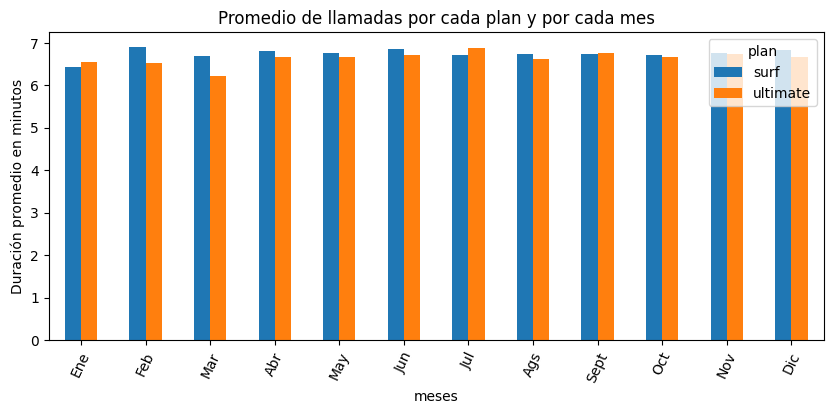

In [ ]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.
calls_media = megaline_calls.merge(megaline_users[['user_id', 'plan']], on='user_id')
calls_media_month = calls_media.pivot_table(index='month', columns='plan', values='duration', aggfunc='mean')

calls_media_month.index=['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ags', 'Sept', 'Oct', 'Nov', 'Dic']
print(calls_media_month.round(2))

calls_media_month.plot(title='Promedio de llamadas por cada plan y por cada mes', kind='bar', ylabel='Duración promedio en minutos',  xlabel="meses" ,rot=65, figsize=[10, 4])
plt.show()



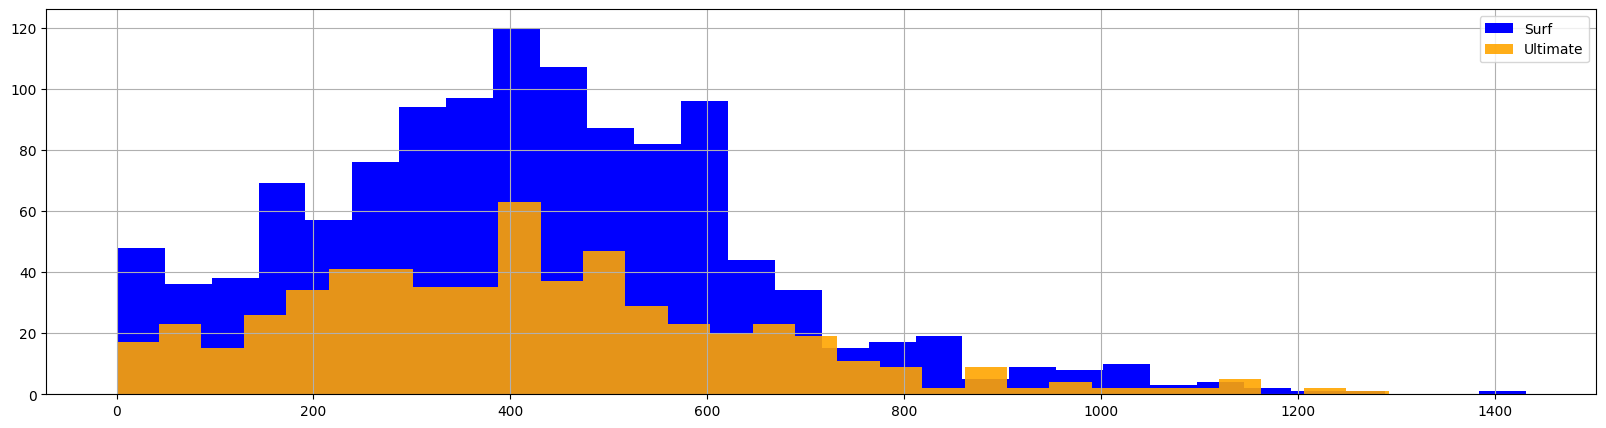

In [ ]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.
surf_duration = user_data[user_data['plan'] == 'surf'].groupby(['user_id', 'month'])['duration'].sum()
ultimate_duration = user_data[user_data['plan'] == 'ultimate'].groupby(['user_id', 'month'])['duration'].sum()

surf_duration.hist(bins=30, color='blue', label='Surf', figsize=[20, 5])
ultimate_duration.hist(bins=30, alpha=0.9, color='orange', label='Ultimate')
plt.legend(['Surf', 'Ultimate'])
plt.show()

In [ ]:
# Calcula la media y la varianza de la duración mensual de llamadas.

calls_var_month = calls_media_month.var()
calls_media_month_mean = calls_media_month.mean()

#monthly_call_mean = user_data['duration'].mean() primer intento
#monthly_call_var = user_data['duration'].var() primer intento

#monthly_call_mean = megaline_calls.groupby(['month', 'plan'])['duration'].mean()
#monthly_call_var = megaline_calls.groupby(['month', 'plan'])['duration'].var()
#print(monthly_call_var, monthly_call_mean)

print('la media por mes es ',calls_media_month_mean.round(2))
print('la varianza por mes es ', calls_var_month.round(2))

la media por mes es  plan
surf        6.75
ultimate    6.64
dtype: float64
la varianza por mes es  plan
surf        0.01
ultimate    0.03
dtype: float64


Distribución de la duracion mensual de llamadas por mes por usuario de cada plan


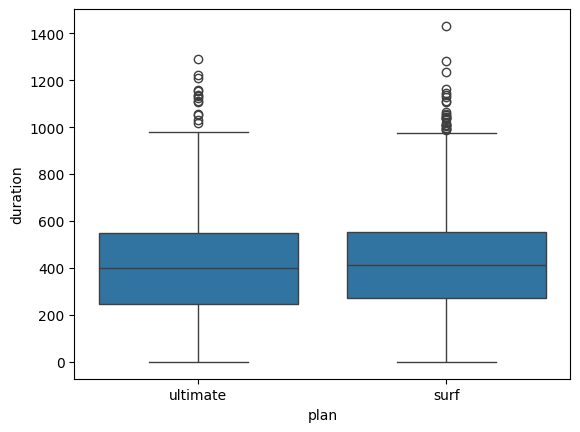

In [ ]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas
print('Distribución de la duracion mensual de llamadas por mes por usuario de cada plan')
sns.boxplot(data=user_data, x='plan', y='duration')
plt.show()

#print('Distribucion de la duracion promedio de llamadas por mes')
#sns.boxplot(data=calls_media_month)
plt.show()

In [ ]:
#calls_media_month

### Mensajes

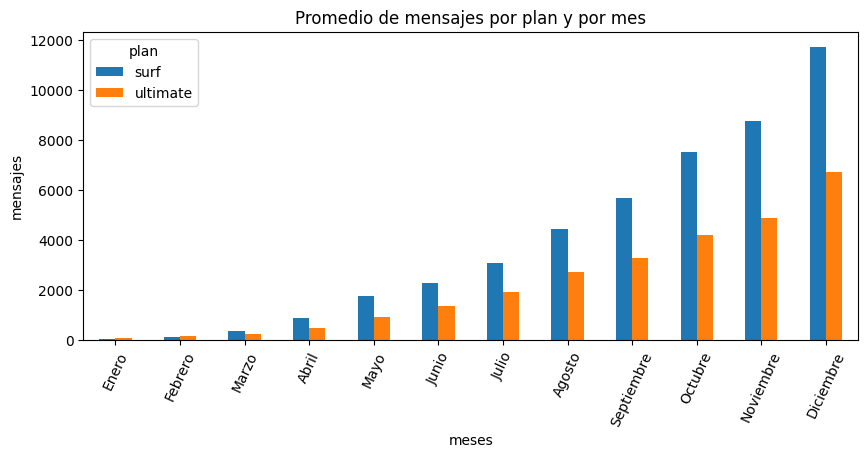

In [ ]:
#sms_media = megaline_messages.merge(megaline_users[['user_id', 'plan']], on='user_id')
sms_media_month = user_data.pivot_table(index='month', columns='plan', values='amount_sms', aggfunc='sum')

sms_media_month.index=['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
sms_media_month.plot(title='Promedio de mensajes por plan y por mes', kind='bar', ylabel='mensajes',  xlabel="meses" ,rot=65, figsize=[10, 4])
plt.show()

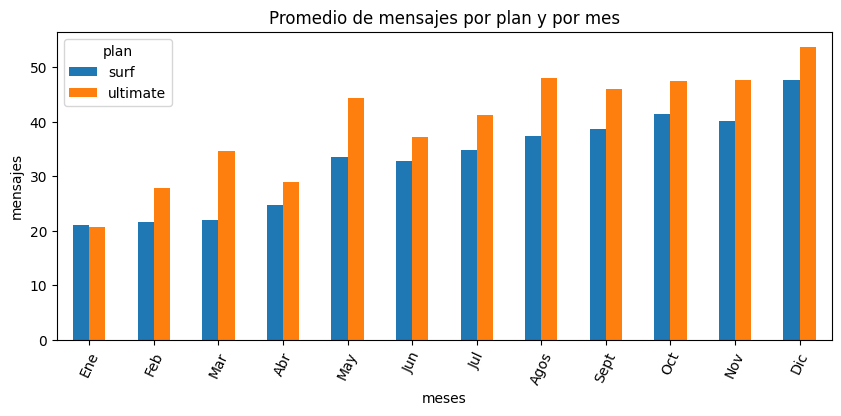

In [ ]:
sms_media_month = user_data.pivot_table(index='month', columns='plan', values='amount_sms', aggfunc='mean')

sms_media_month.index=['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Agos', 'Sept', 'Oct', 'Nov', 'Dic']
sms_media_month.plot(title='Promedio de mensajes por plan y por mes', kind='bar', ylabel='mensajes',  xlabel="meses" ,rot=65, figsize=[10, 4])
plt.show()



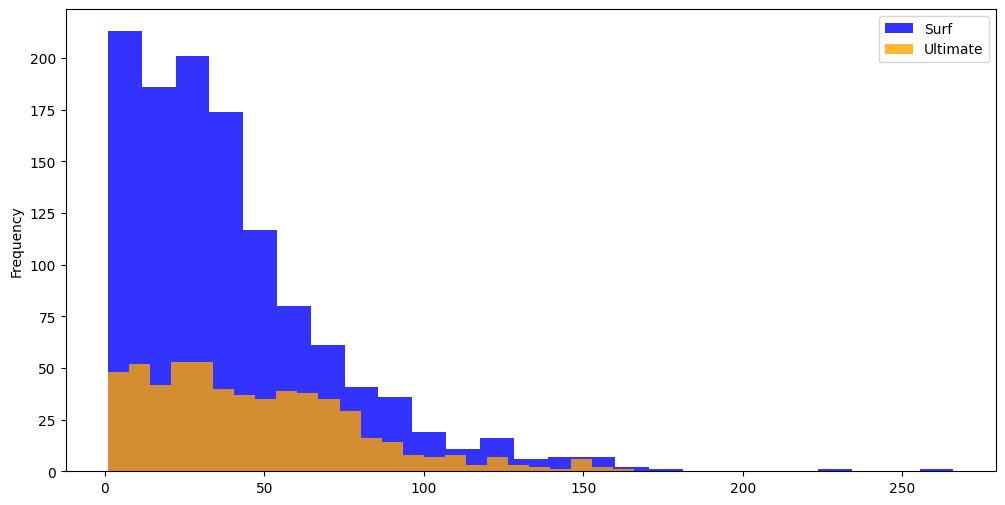

In [ ]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan
surf_sms = user_data[user_data['plan'] == 'surf'].groupby(['user_id', 'month'])['amount_sms'].sum()
ultimate_sms = user_data[user_data['plan'] == 'ultimate'].groupby(['user_id', 'month'])['amount_sms'].sum()

surf_sms.plot(kind='hist', bins=25, alpha=0.8, color='blue', label='Surf', figsize=[12,6])

ultimate_sms.plot(kind='hist',bins=25, alpha=0.8, color='orange', label='Ultimate')
plt.legend(['Surf', 'Ultimate'])
plt.show()


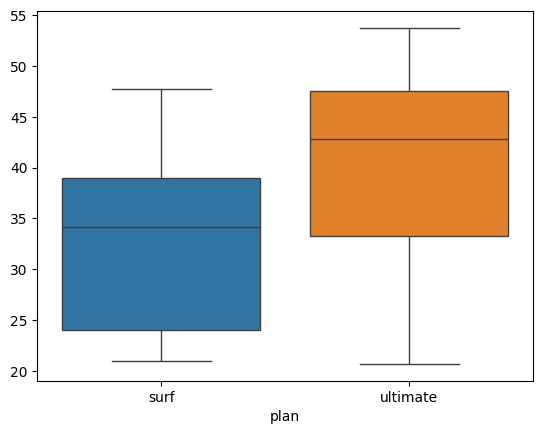

In [ ]:
sns.boxplot(data=sms_media_month)
plt.show()


### Internet

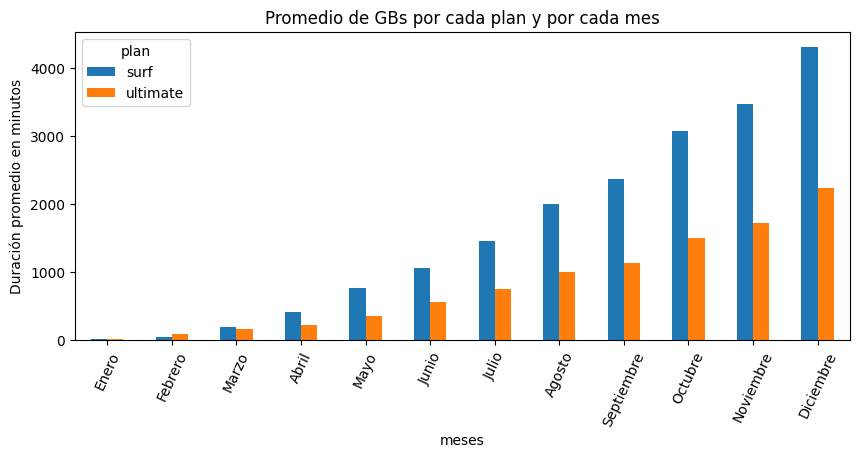

In [ ]:
internet_total_month = user_data.pivot_table(index='month', columns='plan', values='gb_used', aggfunc='sum')

internet_total_month.index=['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
internet_total_month.plot(title='Promedio de GBs por cada plan y por cada mes', kind='bar', ylabel='Duración promedio en minutos',  xlabel="meses" ,rot=65, figsize=[10, 4])
plt.show()

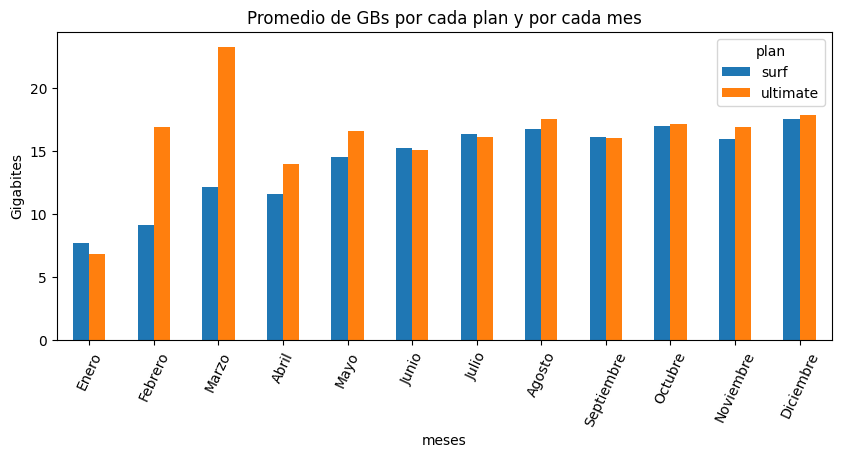

plan         surf  ultimate
Enero        7.71      6.79
Febrero      9.09     16.93
Marzo       12.11     23.28
Abril       11.57     13.95
Mayo        14.50     16.60
Junio       15.20     15.09
Julio       16.32     16.11
Agosto      16.76     17.56
Septiembre  16.11     16.03
Octubre     17.00     17.10
Noviembre   15.92     16.92
Diciembre   17.55     17.84


plan,surf,ultimate
count,12.000000,12.000000
mean,14.152901,16.182224
std,3.264054,3.711356
min,7.710000,6.790000
25%,11.973768,15.791801
50%,15.559606,16.757115
75%,16.427851,17.215350
max,17.547317,23.278571


In [ ]:
internet_media_month = user_data.pivot_table(index='month', columns='plan', values='gb_used', aggfunc='mean')

internet_media_month.index=['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
internet_media_month.plot(title='Promedio de GBs por cada plan y por cada mes', kind='bar', ylabel='Gigabites',  xlabel="meses" ,rot=65, figsize=[10, 4])
plt.show()

print(internet_media_month.round(2))
display(internet_media_month.describe())

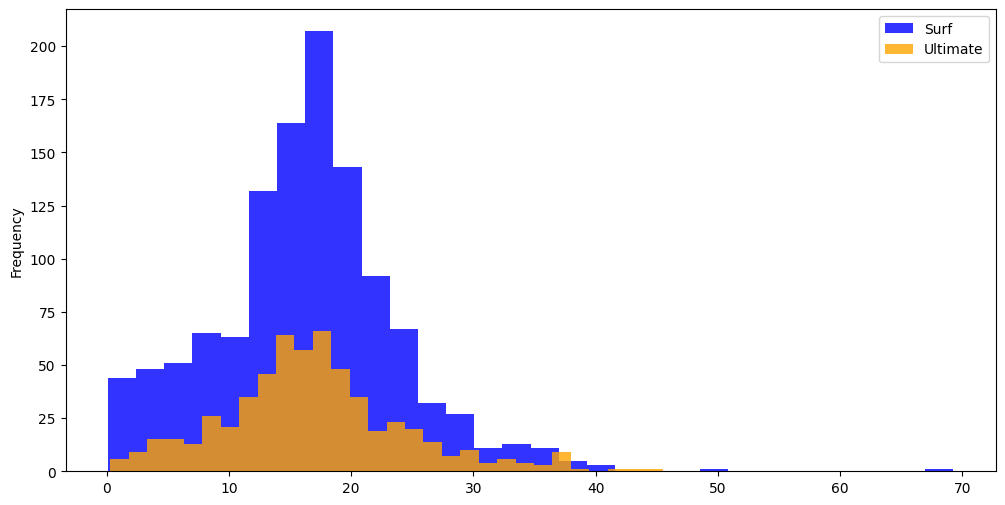

In [ ]:
surf_internet = user_data[user_data['plan'] == 'surf'].groupby(['user_id', 'month'])['gb_used'].sum()
ultimate_internet = user_data[user_data['plan'] == 'ultimate'].groupby(['user_id', 'month'])['gb_used'].sum()


surf_internet.plot(kind='hist', bins=30, alpha=0.8, color='blue', label='Surf', figsize=[12,6])
ultimate_internet.plot(kind='hist',bins=30, alpha=0.8, color='orange', label='Ultimate')
plt.legend(['Surf', 'Ultimate'])
plt.show()

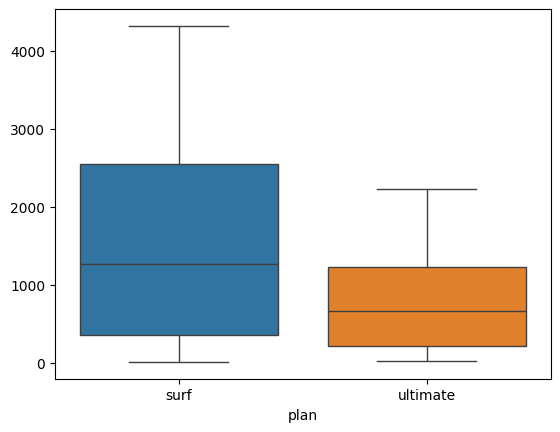

In [ ]:
sns.boxplot(data=internet_media_month)
plt.show()

## Ingreso

plan            surf  ultimate
Enero           0.00      0.00
Febrero        17.71      0.00
Marzo         254.67     40.74
Abril         648.49     48.16
Mayo         1497.81     14.98
Junio        1995.83     69.44
Julio        3418.61    109.20
Agosto       4875.87    131.46
Septiembre   4948.09     88.13
Octubre      7504.02    176.12
Noviembre    7408.44    203.42
Diciembre   10946.38    312.90


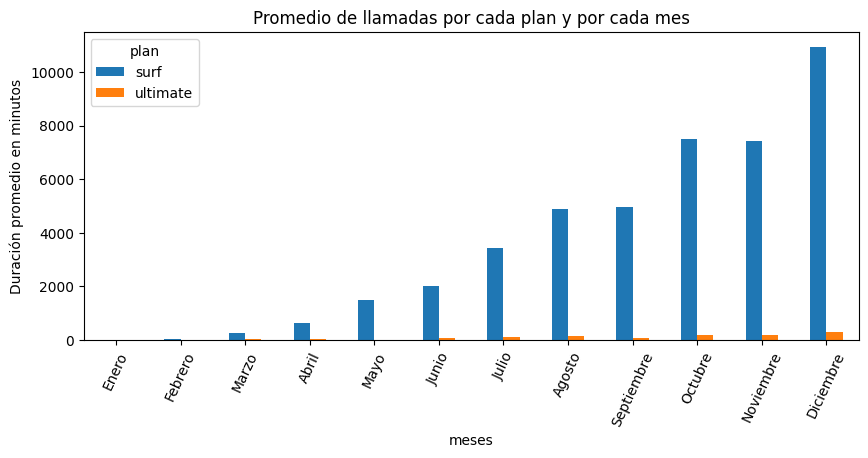

In [ ]:
ingreso_media_month = user_data.pivot_table(index='month', columns='plan', values='monthly_income', aggfunc='sum')


ingreso_media_month.index=['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
print(ingreso_media_month)
ingreso_media_month.plot(title='Promedio de llamadas por cada plan y por cada mes', kind='bar', ylabel='Duración promedio en minutos',  xlabel="meses" ,rot=65, figsize=[10, 4])
plt.show()

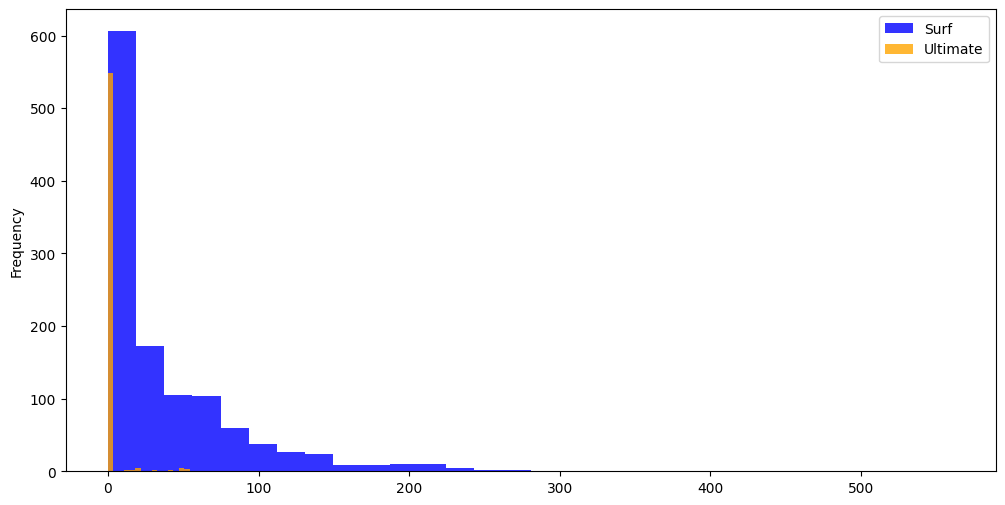

In [ ]:
surf_ingreso = user_data[user_data['plan'] == 'surf'].groupby(['user_id', 'month'])['monthly_income'].sum()
ultimate_ingreso = user_data[user_data['plan'] == 'ultimate'].groupby(['user_id', 'month'])['monthly_income'].sum()

surf_ingreso.plot(kind='hist', bins=30, alpha=0.8, color='blue', label='Surf', figsize=[12,6])
ultimate_ingreso.plot(kind='hist',bins=30, alpha=0.8, color='orange', label='Ultimate')
plt.legend(['Surf', 'Ultimate'])
plt.show()

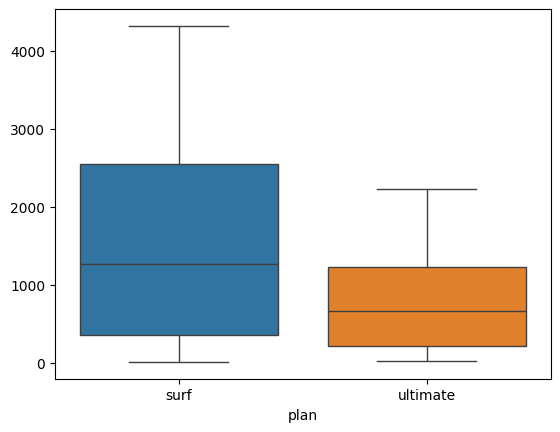

In [ ]:
sns.boxplot(data=internet_media_month)
plt.show()

## Prueba las hipótesis estadísticas

Prueba la hipótesis de que son diferentes los ingresos promedio procedentes de los usuarios de los planes de llamada Ultimate y Surf

In [ ]:
# Prueba las hipótesis
# Hipotesis nula: Los ingresos promedio procedentes de los usuarios son iguales entro los planes Ultimate y Surf
# Hipotesis alternativa: Los ingresos promedio procedentes de los usuarios son diferentes entro los planes Ultimate y Surf
alfa = 0.05
surf_ingreso = user_data[user_data['plan'] == 'surf'].groupby(['user_id'])['monthly_income'].mean()
ultimate_ingreso = user_data[user_data['plan'] == 'ultimate'].groupby(['user_id'])['monthly_income'].mean()
#resultado = st.ttest_ind(surf_ingreso, ultimate_ingreso, equal_var=False)

t_stat, p_val_2tail = st.ttest_ind(surf_ingreso, ultimate_ingreso, equal_var=False)


print(f't_statistic: {t_stat}')
print(f'p_value: {p_val_2tail}')

#if resultado.pvalue < alfa:
if p_val_2tail < alfa:
    print('Rechazamos la hipótesis nula')
else:
    print('No rechazamos la hipótesis nula')

t_statistic: 12.933874887955291
p_value: 1.5818625943479956e-30
Rechazamos la hipótesis nula


Prueba la hipótesis de que el ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones

In [ ]:
# Prueba las hipótesis
#H0 o nula = el ingreso promedio de los usuarios del área NY-NJ es igual al de los usuarios de otras regiones.
#H1 o alternativa = el ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.
alfa = 0.05
user_data_city = user_data.merge(megaline_users[['user_id', 'city']], on='user_id')
NYNJ_ingreso = user_data_city.query('city.str.contains("NY-NJ")').groupby(['user_id'])['monthly_income'].mean()
otros_ingreso = user_data_city.query('not city.str.contains("NY-NJ")').groupby(['user_id'])['monthly_income'].mean()
t_stat, p_val_2tail = st.ttest_ind(NYNJ_ingreso, otros_ingreso, equal_var=False)
print(f'p-valor para 2 colas: {p_val_2tail}')

#p_val_1tail = p_val_2tail / 2
#print(f'p-valor para 1 cola: {p_val_1tail}')

if p_val_2tail < alfa:
    print('Rechazamos la hipótesis nula')
else:
    print('No rechazamos la hipótesis nula, no hay suficientes evidencias para concluir que el ingreso promedio de los usuarios del area de NY-NJ es diferente al de los usuarios de otras regiones')

p-valor para 2 colas: 0.585594048845207
No rechazamos la hipótesis nula, no hay suficientes evidencias para concluir que el ingreso promedio de los usuarios del area de NY-NJ es diferente al de los usuarios de otras regiones


## Conclusión general

Se recibe una muestra de la empresa 'Megaline' del año 2018 donde se registraron 500 usuarios, con el fin de poder 'saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad'.
Una vez observados los datos, primero se corrigieron ciertos errores: nombres en columnas para poder combinarlas más adelante, también se segmentaron los datos en meses, para poder entender mejor cómo fue el comportamiento de los clientes a lo largo del año.
Primera observación general:

Se observa mayor cantidad de usuarios del plan Surf.
Se observa un crecimiento en ambos planes en cuanto a la cantidad de actividad por mes, esto puede referirse a nuevos clientes.
Primeras conclusiones en cuanto a llamadas:

La cantidad promedio de llamadas para ambos usuarios es entre 6.4 y 6.8 minutos. Es decir, no hay diferencias significativas.
La distribución de los datos en cuanto al número utilizado de minutos mensuales por usuario es similar.
Primeras conclusiones en cuanto a mensajes:

Al hacer un promedio de qué usuarios envían mayor cantidad de mensajes por mes estos corresponden a los clientes de Ultimate.
El comportamiento de los usuarios en cuanto al número de mensajes que tiende a enviar por mes es similar.
Primeras conclusiones en cuanto a al uso de GBs:

La cantidad de GBs utilizadas por usuario por mes tiene una media similar en cada plan, pero los usuarios de Ultimate utilizan mayor volumen de internet mismo. Se observa gran consumo de los mismos en los meses de febrero y enero.
El comportamiento en al distribucion de los datos es similar.
La media de volumen de internet de Surf es de 14GB por mes, mientras que Ultimate es de 16GB.
Conclusiones en cuanto a ingresos: Con un 95% de certeza, los usuarios de Surf generan mayor cantidad de ingresos en comparación a los de Ultimate. Esto se corrobora con gráficos y una hipótesis nula y otra alternativa.
